Final Project
Jack Schwyn

DataSet:
Gas Turbine CO and NOx Emission Data Set. (2019). UCI Machine Learning Repository. https://doi.org/10.24432/C5WC95.

Variables:
Ambient Temperature- AT
Ambient Pressure- AP
Ambient humidity- AH
Air filter differnece pressure- AFDP
Gas turbine exhaust pressure- GTEP
Turbine inlet temperature- TIT
Turbine after temperature- TAT
Compressor discharge pressure- CDP
Turbine energy yield- TEY
Carbon monoxide- CO
Nitrogen oxides- NOx

The size of the dataset is 7384 by 11. This mean that there are 7384 rows and 11 columns, or 11 features.

Since there are 11 features, it will be useful to build a sns.heatmap to see if there are strong correlations between the features.
There are three things we can predict from this data set: Turbine Energy yield, Carbon Monoxide emissions, and Nitrogen oxide emission. With a correlation heatmap we can see what features have a strong correlation to what we want to predict, and then build a regression model.

Since this is a large dataset, there will msot likely be outliers which we can find with boxplots. In order for our prediciton models to be accurate we will have to get rid of these outliers (or most of them), and make sure that we still have a substantial dataset.

Since this dataset does not have any categorial features (this dataset had strong correlations), we will be using a simple linear regression model as well as a multiple linear regression model. We will create two multiple linear regression models, one using all the features to predict CO emissions, and another one where the features have a strong correlation to CO emissions (a correlation score above 0.5), and compare the R2 scores.

In retrospect, I should have maybe chosen a dataset with categorial values to add another layer of complexity, but I believe that I will still be able to draw useful information from this dataset. .

Based ontheefeatures or variabless, the manufacturers of the turbine can predict the turbine's energy yield, as well as how much (in mg/m^3) carbon monoxide and nitrogen monoxide is emitted from the turbine. If they want to emit less carbon monoxide, they can find what variables or features correlate to carbon monixed emissions, and build the turbine based on those variables.



In [315]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import metrics
from sklearn.metrics import r2_score
from sklearn import linear_model
from sklearn.metrics import roc_curve
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score

In [316]:
df = pd.read_csv("gt_2015.csv", skipinitialspace = True) #Importing original dataset.
#Show data
df

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
0,1.95320,1020.1,84.985,2.5304,20.116,1048.7,544.92,116.27,10.799,7.4491,113.250
1,1.21910,1020.1,87.523,2.3937,18.584,1045.5,548.50,109.18,10.347,6.4684,112.020
2,0.94915,1022.2,78.335,2.7789,22.264,1068.8,549.95,125.88,11.256,3.6335,88.147
3,1.00750,1021.7,76.942,2.8170,23.358,1075.2,549.63,132.21,11.702,3.1972,87.078
4,1.28580,1021.6,76.732,2.8377,23.483,1076.2,549.68,133.58,11.737,2.3833,82.515
...,...,...,...,...,...,...,...,...,...,...,...
7379,3.62680,1028.5,93.200,3.1661,19.087,1037.0,541.59,109.08,10.411,10.9930,89.172
7380,4.16740,1028.6,94.036,3.1923,19.016,1037.6,542.28,108.79,10.344,11.1440,88.849
7381,5.48200,1028.5,95.219,3.3128,18.857,1038.0,543.48,107.81,10.462,11.4140,96.147
7382,5.88370,1028.7,94.200,3.9831,23.563,1076.9,550.11,131.41,11.771,3.3134,64.738


In [317]:
#Check for missing values
df = df.dropna()
df

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
0,1.95320,1020.1,84.985,2.5304,20.116,1048.7,544.92,116.27,10.799,7.4491,113.250
1,1.21910,1020.1,87.523,2.3937,18.584,1045.5,548.50,109.18,10.347,6.4684,112.020
2,0.94915,1022.2,78.335,2.7789,22.264,1068.8,549.95,125.88,11.256,3.6335,88.147
3,1.00750,1021.7,76.942,2.8170,23.358,1075.2,549.63,132.21,11.702,3.1972,87.078
4,1.28580,1021.6,76.732,2.8377,23.483,1076.2,549.68,133.58,11.737,2.3833,82.515
...,...,...,...,...,...,...,...,...,...,...,...
7379,3.62680,1028.5,93.200,3.1661,19.087,1037.0,541.59,109.08,10.411,10.9930,89.172
7380,4.16740,1028.6,94.036,3.1923,19.016,1037.6,542.28,108.79,10.344,11.1440,88.849
7381,5.48200,1028.5,95.219,3.3128,18.857,1038.0,543.48,107.81,10.462,11.4140,96.147
7382,5.88370,1028.7,94.200,3.9831,23.563,1076.9,550.11,131.41,11.771,3.3134,64.738


The size stays the same, there are not missing values.

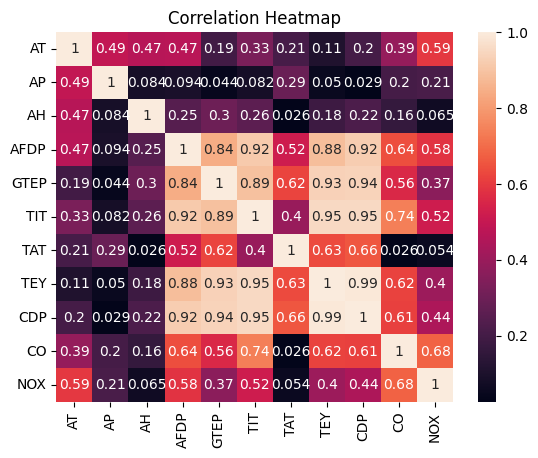

In [318]:
#Correlation Heatmap
sns.heatmap(df.corr().abs(), annot = True) #Creating the heatmapa
plt.title("Correlation Heatmap")
plt.show()

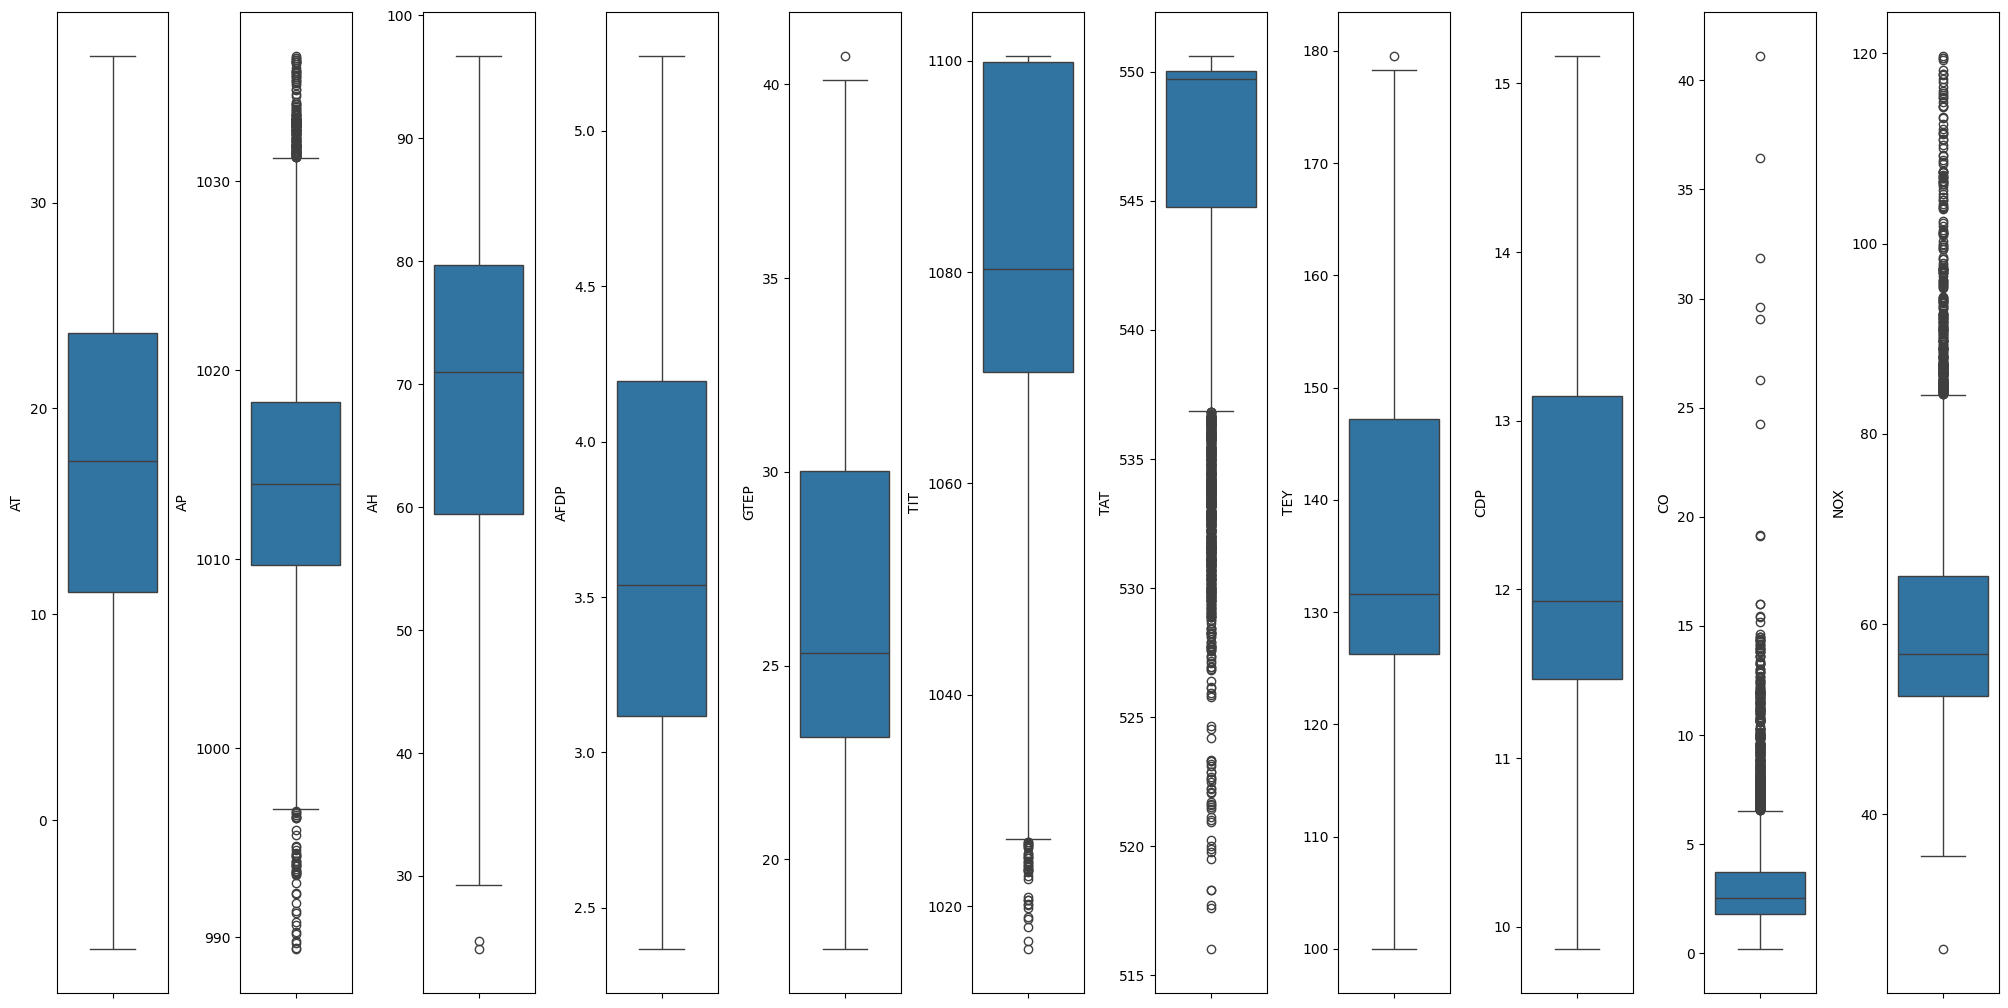

In [319]:
#Using boxplost to look for outliers.
fig, axs = plt.subplots(ncols = 11, nrows = 1, figsize = (20,10))
index = 0
axs = axs.flatten()
for k, v in df.items():
    sns.boxplot(y = k, data = df, ax = axs[index])
    index += 1
plt.tight_layout(pad=0.4, w_pad = 0.5, h_pad = 0.5)

In [320]:
#We are going to use a Multiple Linear Regression model to predict CO emissions, before we get rid of the outliers
X = df.drop('CO', axis = 1) #Separating the CO column from the rest of the data.
y = df['CO']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/3, random_state = 0) #Splitting the data into training and testing sets.
print(X_test)
print(y_test)

           AT      AP      AH    AFDP    GTEP     TIT     TAT     TEY     CDP  \
6307  15.1250  1020.1  74.117  3.3236  23.979  1077.1  549.79  130.47  11.702   
5036  33.5700  1008.2  39.263  4.0399  25.802  1085.0  550.49  130.45  12.150   
1995  11.1370  1009.6  62.082  3.3141  26.668  1080.6  550.38  135.58  11.970   
4156  30.1020  1005.7  56.180  4.2401  29.218  1099.8  548.08  145.39  12.957   
6328  16.6980  1022.5  58.083  2.5680  17.984  1030.5  542.61  100.71  10.148   
...       ...     ...     ...     ...     ...     ...     ...     ...     ...   
1203  10.0560  1014.1  73.156  3.2421  23.981  1076.5  549.92  131.60  11.786   
1418   8.5844  1015.1  73.706  2.6515  19.665  1042.9  547.66  109.50  10.404   
5413  24.7850  1006.6  62.402  4.6644  30.117  1100.1  544.24  149.51  13.250   
5856  20.5240  1017.9  72.246  3.3082  24.162  1078.1  550.32  129.74  11.902   
4574  28.8130  1008.0  69.032  4.4062  29.505  1100.0  547.07  145.32  13.052   

         NOX  
6307  55.445

In [321]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

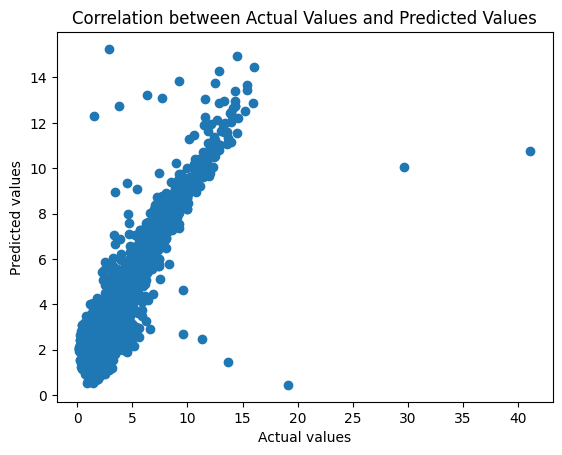

R2 Score 0.8048733817347833


In [322]:
#Prediciton vs actual
y_pred = regressor.predict(X_train)
plt.scatter(y_train, y_pred)
plt.title("Correlation between Actual Values and Predicted Values")
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.show()
print("R2 Score", r2_score(y_train,y_pred))

Even with outliers, our multiple linear regression prediction model for prediciting CO Emissions is relatively accurate (R2 Score = 0.805). Now, let us go ahead and remove these outliers.

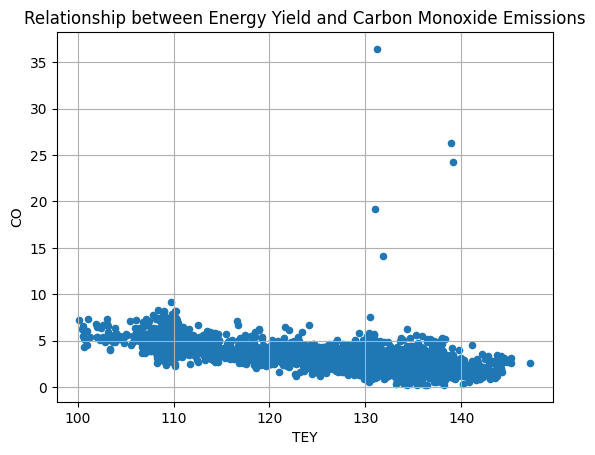

In [323]:
#Scatter Plot
data.plot.scatter(x = 'TEY', y = 'CO') #Showing a relationship between Total Energy Yield and Carbon Monoxide Emissions.
#There are no outliers for CO.
plt.title("Relationship between Energy Yield and Carbon Monoxide Emissions")
plt.grid()
plt.show()

As you can see, there are still CO outliers that need to be removed. Especially if we want to accurately predict CO emissions.

In [324]:
finaldata = data[~(data['CO'] >= 6)]
finaldata

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
2,0.94915,1022.2,78.335,2.7789,22.264,1068.8,549.95,125.88,11.256,3.6335,88.147
3,1.00750,1021.7,76.942,2.8170,23.358,1075.2,549.63,132.21,11.702,3.1972,87.078
4,1.28580,1021.6,76.732,2.8377,23.483,1076.2,549.68,133.58,11.737,2.3833,82.515
5,1.83190,1021.7,76.411,2.8410,23.495,1076.4,549.92,133.58,11.829,2.0812,81.193
6,2.07400,1022.0,75.974,2.7981,22.945,1073.7,549.98,131.53,11.687,2.2529,83.171
...,...,...,...,...,...,...,...,...,...,...,...
7358,2.80400,1028.5,85.691,3.3807,22.541,1072.4,549.83,127.91,11.552,3.5429,68.581
7359,2.45840,1028.6,85.003,3.3503,22.643,1073.1,549.81,128.65,11.505,3.6427,68.059
7377,3.42180,1028.7,91.003,3.6911,22.859,1073.5,549.78,129.86,11.549,3.6738,67.737
7378,3.37760,1028.5,92.703,3.3128,20.248,1057.6,550.30,117.46,10.783,5.3488,66.550


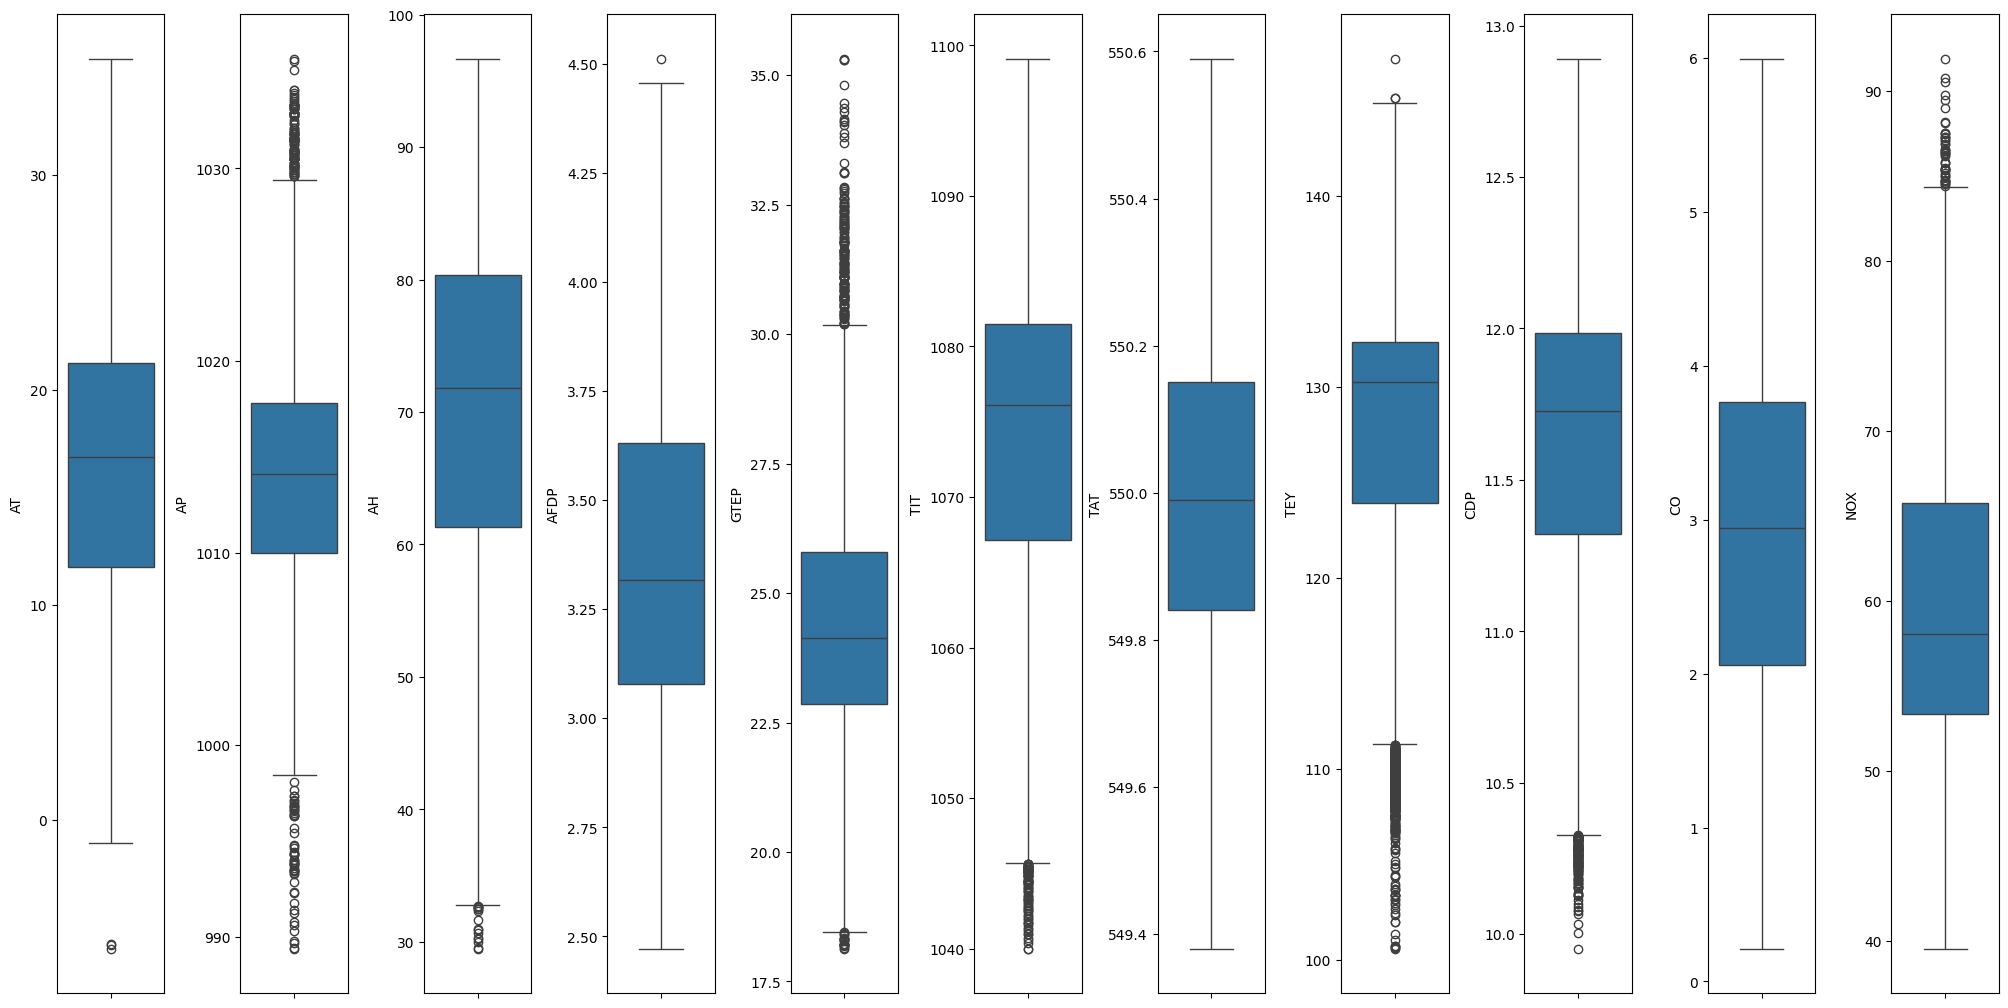

In [325]:
fig, axs = plt.subplots(ncols = 11, nrows = 1, figsize = (20,10))
index = 0
axs = axs.flatten()
for k, v in finaldata.items():
    sns.boxplot(y = k, data = finaldata, ax = axs[index])
    index += 1
plt.tight_layout(pad=0.4, w_pad = 0.5, h_pad = 0.5)

CO outliers have been removed.

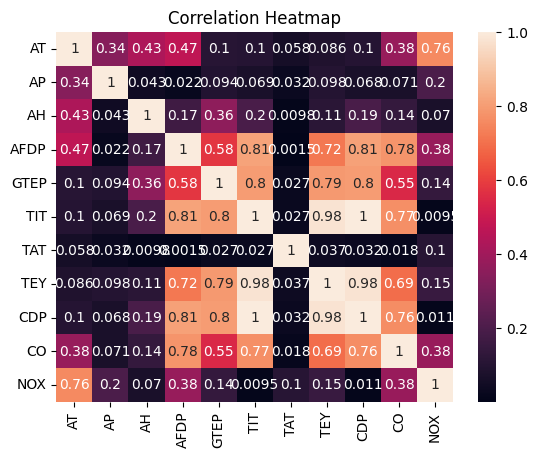

In [355]:
#New Correlation Heatmap
sns.heatmap(finaldata.corr().abs(), annot = True) #Creating the heatmapa
plt.title("Correlation Heatmap")
plt.show()

The feature that has the strongest correlation with CO emissions is AFDP, with a correlation score of 0.78.

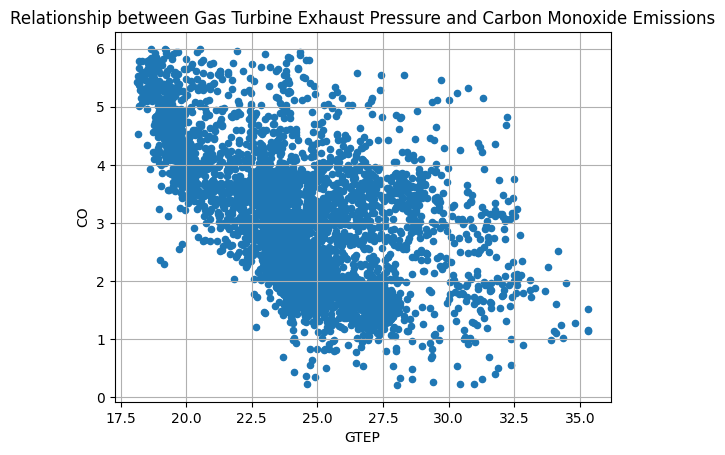

In [356]:
#New Scatter Plot
finaldata.plot.scatter(x = 'GTEP', y = 'CO') #Showing a relationship between Gas Turbine Exhaust Pressure and Carbon Monoxide Emissions.
#There are no outliers for CO.
plt.title("Relationship between Gas Turbine Exhaust Pressure and Carbon Monoxide Emissions")
plt.grid()
plt.show()

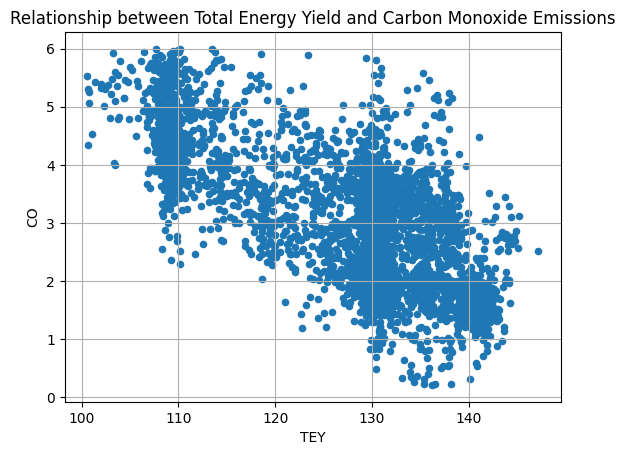

In [357]:
finaldata.plot.scatter(x = 'TEY', y = 'CO') #Showing a relationship between Total Energy Yield and Carbon Monoxide Emissions.
#There are no outliers for CO.
plt.title("Relationship between Total Energy Yield and Carbon Monoxide Emissions")
plt.grid()
plt.show()

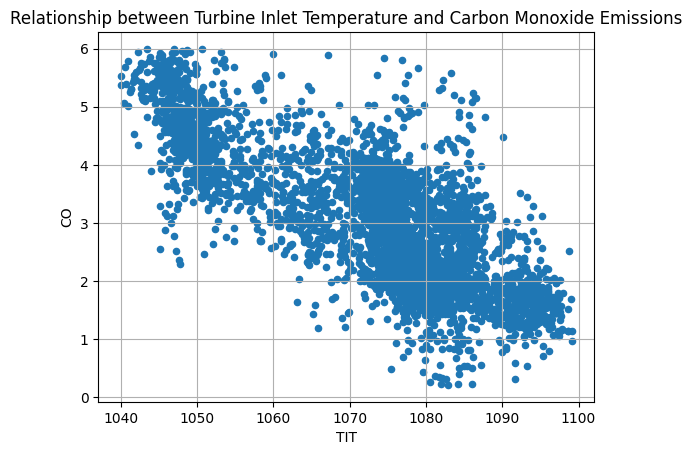

In [358]:
finaldata.plot.scatter(x = 'TIT', y = 'CO') #Showing a relationship between Turbine Inlet Temperature and Carbon Monoxide Emissions.
#There are no CO outliers.
plt.title("Relationship between Turbine Inlet Temperature and Carbon Monoxide Emissions")
plt.grid()
plt.show()

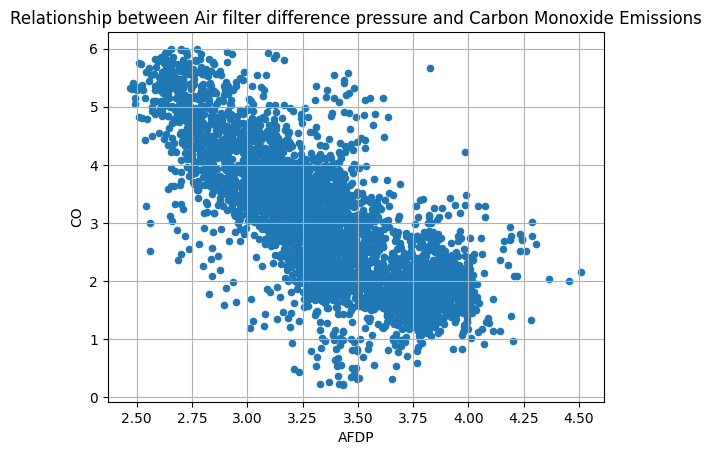

In [359]:
finaldata.plot.scatter(x = 'AFDP', y = 'CO') #Showing a relationship between Air filter differnece pressure and Carbon Monoxide Emissions.
#There are no CO outliers.
plt.title("Relationship between Air filter difference pressure and Carbon Monoxide Emissions")
plt.grid()
plt.show()

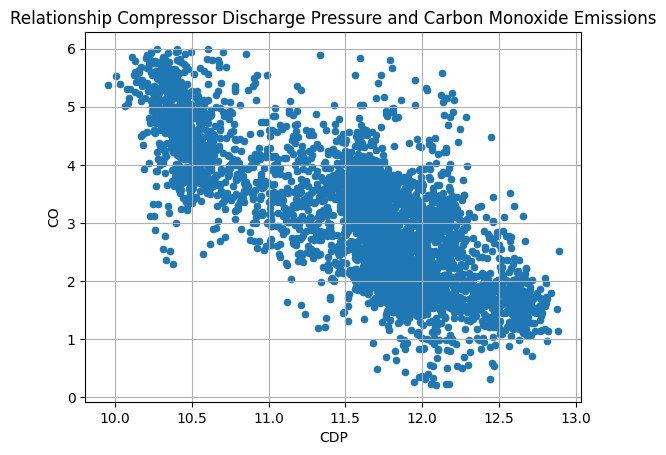

In [360]:
finaldata.plot.scatter(x = 'CDP', y = 'CO') #Showing a relationship between Compressor Discharge Pressure and Carbon Monoxide Emissions.
#There are no CO outliers.
plt.title("Relationship Compressor Discharge Pressure and Carbon Monoxide Emissions")
plt.grid()
plt.show()

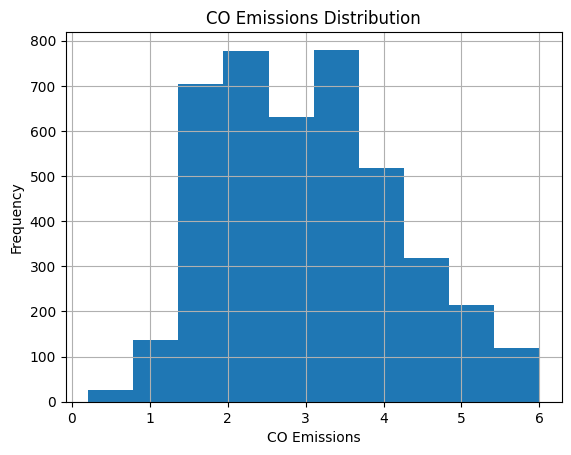

In [361]:
COarray = finaldata['CO'].to_numpy()
plt.hist(COarray)
plt.xlabel("CO Emissions")
plt.ylabel("Frequency")
plt.title("CO Emissions Distribution")
plt.grid()
plt.show()

In [362]:
#Summary statistics fo CO Emissions
mean = finaldata.CO.mean() #Mean
median = finaldata.CO.median() #Median
#Print statements
print("CO Emissions in mg/m^3:")
print("Mean: ", mean)
print("Median: ", median)

CO Emissions in mg/m^3:
Mean:  3.0236173456352025
Median:  2.9492


In [332]:
#Simple Linear Regression, predicting CO emissiosn based on AFDP (strongest correlation based on the heatmap) 
X = finaldata['AFDP'].values
y = finaldata['CO'].values
X = np.reshape(X, (-1,1))
shape = X.shape
print(shape)
print(X)
print(y)

(4227, 1)
[[2.7789]
 [2.817 ]
 [2.8377]
 ...
 [3.6911]
 [3.3128]
 [3.9831]]
[3.6335 3.1972 2.3833 ... 3.6738 5.3488 3.3134]


In [333]:
#Test train split and building the linear regression model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/3, random_state = 0) #Splitting the data into training and testing sets.
print(X_test)
print(y_test)

[[3.2785]
 [3.1743]
 [3.6391]
 ...
 [3.0806]
 [2.7286]
 [3.2689]]
[2.469  3.1837 1.7847 ... 3.3849 4.759  2.973 ]


In [334]:
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

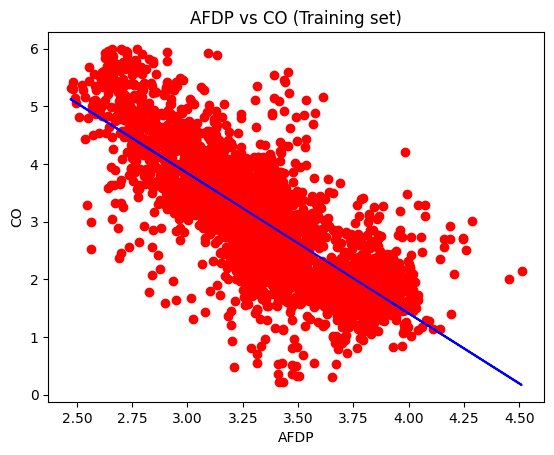

In [335]:
#Visualising the Training results
plt.scatter(X_train, y_train, color = 'red')
plt.plot(X_train, regressor.predict(X_train), color = 'blue')
plt.title('AFDP vs CO (Training set)')
plt.xlabel('AFDP')
plt.ylabel('CO')
plt.show()

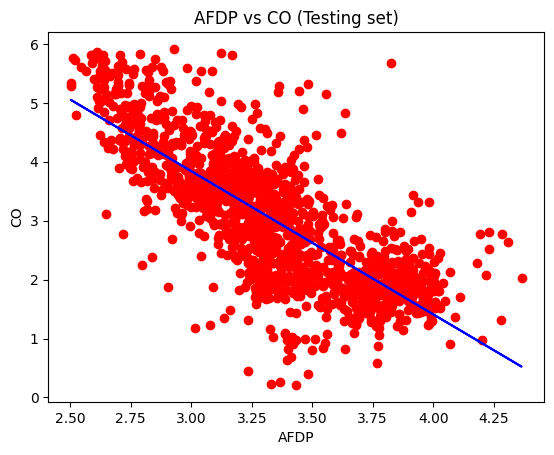

In [336]:
#Visualising the Testing results
plt.scatter(X_test, y_test, color = 'red')
plt.plot(X_test, regressor.predict(X_test), color = 'blue')
plt.title('AFDP vs CO (Testing set)')
plt.xlabel('AFDP')
plt.ylabel('CO')
plt.show()

In [337]:
#Linear Regression Equation
print(regressor.coef_)
print(regressor.intercept_)

[-2.42947315]
11.12839070696625


Equation for the Linear Regression model based on AFDP and CO: CO = -2.43 *AFDP + 11.1284

We can use this equation to predict the CO emissions based on the AFDP.

In [338]:
y_pred = regressor.predict(X_test)
y_pred = regressor.predict(X_test)
print( "R2 Score", r2_score(y_test,y_pred))

R2 Score 0.5990765155568787


The R2 score being 0.60 means that this model can somewhat accuratley predict the CO emissions based on the feature that has the strongest correlation, but it should not be the only way to predict CO emissions.

In [339]:
#Now we are going to use a Multiple Linear Regression model to predict CO emissions.
X = finaldata.drop('CO', axis = 1) #Separating the CO column from the rest of the data.
y = finaldata['CO']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/3, random_state = 0) #Splitting the data into training and testing sets.
print(X_test)
print(y_test)

          AT      AP      AH    AFDP    GTEP     TIT     TAT     TEY     CDP  \
6432  17.700  1023.3  66.319  3.2785  23.948  1077.0  550.45  129.62  11.790   
6810  11.792  1010.1  86.528  3.1743  22.337  1067.0  550.01  124.61  11.337   
2390  17.042  1013.3  86.284  3.6391  26.327  1091.2  549.99  140.74  12.385   
5515  23.217  1010.8  83.522  3.4518  22.094  1063.7  550.32  118.63  11.156   
1523  17.511  1004.7  63.654  3.3857  29.473  1080.1  550.34  133.10  11.964   
...      ...     ...     ...     ...     ...     ...     ...     ...     ...   
2102  15.650  1016.9  71.278  3.3619  27.381  1081.7  549.70  133.66  12.035   
2763  19.358  1011.1  49.149  3.2115  22.847  1068.8  550.16  123.79  11.372   
473   12.794  1011.2  72.863  3.0806  24.599  1075.5  549.90  130.63  11.695   
6393  15.710  1015.2  73.601  2.7286  19.096  1047.9  550.42  109.51  10.444   
6566  12.147  1015.8  75.156  3.2689  23.509  1074.3  550.15  129.72  11.650   

         NOX  
6432  55.174  
6810  58.

In [340]:
#Standard Scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train) #Transforming the training set into an array.
X_test = sc.transform(X_test) #Transforming the testing set into an array.
X_test

array([[ 0.17147242,  1.39285576, -0.2621563 , ...,  0.2198191 ,
         0.31413493, -0.51360407],
       [-0.70208072, -0.63787996,  1.27219839, ..., -0.29761156,
        -0.40105817, -0.15813666],
       [ 0.07418096, -0.14558039,  1.25367286, ...,  1.36828793,
         1.25351659, -0.35647389],
       ...,
       [-0.55392564, -0.46865198,  0.23469249, ...,  0.32413146,
         0.16414962,  0.74875806],
       [-0.12276772,  0.14672248,  0.29072464, ..., -1.85713308,
        -1.81092006, -0.14070291],
       [-0.64959065,  0.23902865,  0.40878697, ...,  0.23014705,
         0.09310395,  0.03261575]])

In [341]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

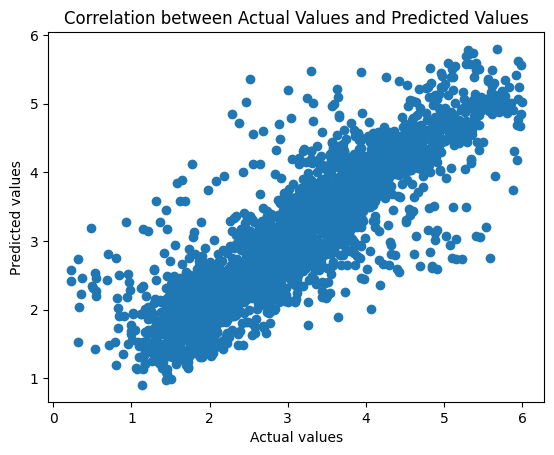

In [342]:
#Prediciton vs actual
y_pred = regressor.predict(X_train)
plt.scatter(y_train, y_pred)
plt.title("Correlation between Actual Values and Predicted Values")
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.show()

In [343]:
#Predicting Test Results
print( "R2 Score", r2_score(y_train,y_pred))

R2 Score 0.7549291995353192


When we get rid of the outliers, the R2 score decreses to 0.7549. I beleive this model, while slightley less acurrate, will be more beneficial for predictions because we are removing outliers.

Based on the R2 scores, the multilpe regression model is better than the simple linear regression. This is because we are using more features that have a strong correlation to CO emissions. Features like AFDP, GTEP, TIT, TEY, and CDP.

In [344]:
#Relevant features
X = finaldata.drop(['CO', 'AT', 'AP', 'AH', 'TAT', 'NOX'], axis = 1) #Separating the CO column from the rest of the data.
y = finaldata['CO']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/3, random_state = 0) #Splitting the data into training and testing sets.
print(X_test)
print(y_test)

        AFDP    GTEP     TIT     TEY     CDP
6432  3.2785  23.948  1077.0  129.62  11.790
6810  3.1743  22.337  1067.0  124.61  11.337
2390  3.6391  26.327  1091.2  140.74  12.385
5515  3.4518  22.094  1063.7  118.63  11.156
1523  3.3857  29.473  1080.1  133.10  11.964
...      ...     ...     ...     ...     ...
2102  3.3619  27.381  1081.7  133.66  12.035
2763  3.2115  22.847  1068.8  123.79  11.372
473   3.0806  24.599  1075.5  130.63  11.695
6393  2.7286  19.096  1047.9  109.51  10.444
6566  3.2689  23.509  1074.3  129.72  11.650

[1409 rows x 5 columns]
6432    2.4690
6810    3.1837
2390    1.7847
5515    3.3158
1523    1.0890
         ...  
2102    5.2916
2763    2.8022
473     3.3849
6393    4.7590
6566    2.9730
Name: CO, Length: 1409, dtype: float64


In [345]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train) #Transforming the training set into an array.
X_test = sc.transform(X_test) #Transforming the testing set into an array.
X_test

array([[-0.16393951, -0.10447989,  0.28682023,  0.2198191 ,  0.31413493],
       [-0.44835006, -0.64944828, -0.46444798, -0.29761156, -0.40105817],
       [ 0.82030659,  0.70028721,  1.3536211 ,  1.36828793,  1.25351659],
       ...,
       [-0.70410119,  0.11574011,  0.17413   ,  0.32413146,  0.16414962],
       [-1.66487386, -1.74581238, -1.89937027, -1.85713308, -1.81092006],
       [-0.1901424 , -0.25298462,  0.08397782,  0.23014705,  0.09310395]])

In [346]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

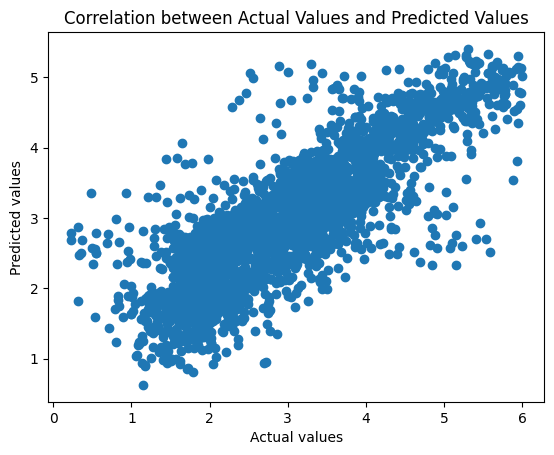

In [347]:
#Prediciton vs actual
y_pred = regressor.predict(X_train)
plt.scatter(y_train, y_pred)
plt.title("Correlation between Actual Values and Predicted Values")
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.show()

In [348]:
#Predicting Test Results
print("R2 Score", r2_score(y_train,y_pred))

R2 Score 0.6919624038548089


Here, we are predicting CO emissions based on the "relevant features" or the features with strong correlations (based on the heatmap). The R2 score decreased, which means that if we want the best results for our prediciton model, we need to consider all of the variables/features in the dataset.

If the manufacturers of the gas turbine want to limit CO emissions, they should consider all of the features of the Gas Turbine. However, if they used the features that have a strong correlation to CO emissions, they can still somewhat accurately predict their CO emissions. At the very least these 5 features will give the manufacturers a basic idea of what to adjust. For example, according to the scatter plot, if they want to decrease CO emissions, they could adjust their turbine so that the air filter difference pressure will increase.